## השוואות ומסכות בוליאניות, where, any, all

אופרטורי השוואה (`>`, `<`, `==` וכו') על מערך NumPy אינם מחזירים ערך יחיד — הם מחזירים **מערך בוליאני** באותו גודל, עם `True`/`False` לכל איבר. מערך כזה נקרא **מסכה (mask)**, ואפשר להשתמש בו כדי לסנן את המערך המקורי: `a[mask]` מחזיר רק את האיברים שבהם המסכה `True`.

שלוש פונקציות שימושיות שמבוססות על מסכות:
- `np.where(mask)` — מחזיר את **האינדקסים** שבהם המסכה `True`.
- `np.any(mask)` — `True` אם **לפחות** איבר אחד במסכה הוא `True`.
- `np.all(mask)` — `True` רק אם **כל** האיברים במסכה הם `True`.

### דוגמה: מציאת רגע הנחיתה

עבור מסלול הזריקה $y(t) = v_0 t - \tfrac{1}{2} g t^2$, הביטוי הזה ממשיך להיות מוגדר מתמטית גם לאחר שהכדור פגע בקרקע ($y<0$) — אבל פיזיקלית זה חסר משמעות. נשתמש במסכה כדי לזהות ולחתוך את החלק הרלוונטי בלבד.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g, v0 = 9.8, 15.0
t = np.linspace(0, 4, 40)
y = v0 * t - 0.5 * g * t**2

above_ground = y >= 0
print("מסכה (10 ראשונים):", above_ground[:10])
print("יש נקודות מתחת לקרקע?", np.any(~above_ground))
print("כל הנקודות מעל הקרקע?", np.all(above_ground))

מסכה (10 ראשונים): [ True  True  True  True  True  True  True  True  True  True]
יש נקודות מתחת לקרקע? True
כל הנקודות מעל הקרקע? False


In [2]:
landing_idx = np.where(~above_ground)[0][0]   # האינדקס הראשון שבו y שלילי
print("אינדקס הנחיתה:", landing_idx, " t =", t[landing_idx])

t_flight = t[above_ground]
y_flight = y[above_ground]

אינדקס הנחיתה: 30  t = 3.0769230769230766


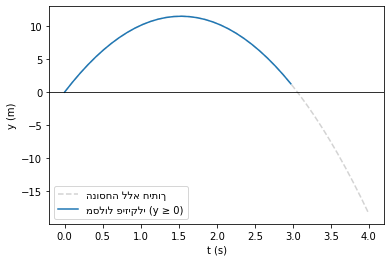

In [3]:
fig, ax = plt.subplots()
ax.plot(t, y, "--", color="lightgray", label="הנוסחה ללא חיתוך")
ax.plot(t_flight, y_flight, color="tab:blue", label="מסלול פיזיקלי (y ≥ 0)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("t (s)")
ax.set_ylabel("y (m)")
ax.legend()
plt.show()

### נסו בעצמכם

בנו מסכה של הנקודות שבהן הגובה עולה על 5 מטרים, וספרו כמה נקודות כאלה יש:

In [4]:
# high_mask = ...
# n_high = ...
# print(n_high)

`````{admonition} פתרון
:class: dropdown, tip
```python
high_mask = y > 5
n_high = np.sum(high_mask)   # True נספר כ-1
print(n_high)
```
`````

### בדקו את עצמכם

In [5]:
from jupyterquiz import display_quiz

questions = [
    {
        "question": "בהינתן <code>a = np.array([1, -2, 3, -4])</code>, מה מחזיר <code>a[a > 0]</code>?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "[True, False, True, False]", "correct": False, "feedback": "זו התוצאה של a > 0 עצמו, לא של a[a > 0]."},
            {"answer": "[1, 3]", "correct": True, "feedback": "נכון: המסכה משמשת לסינון — רק האיברים החיוביים נשארים."},
            {"answer": "שגיאה, כי אי אפשר לאנדקס עם מערך בוליאני", "correct": False, "feedback": "לא — זה בדיוק השימוש המרכזי במסכות."},
            {"answer": "[-2, -4]", "correct": False, "feedback": "לא — המסכה משאירה רק את האיברים שמקיימים את התנאי (חיוביים), לא את השליליים."}
        ]
    }
]

display_quiz(questions)

<IPython.core.display.Javascript object>

### תרגול עצמי

חיישן מדד את גובה כדור לאורך ניסוי, אך עקב תקלה חשמלית חלק מהקריאות יצאו שליליות — דבר בלתי אפשרי פיזיקלית עבור הניסוי הזה. סננו את כל הקריאות התקינות (הלא-שליליות) בלבד:

In [6]:
sensor_readings = np.array([2.1, 3.4, -0.5, 4.0, -1.2, 5.5, 0.0])

# valid_mask = ...
# valid_readings = ...
# print(valid_readings)

`````{admonition} פתרון
:class: dropdown, tip
```python
valid_mask = sensor_readings >= 0
valid_readings = sensor_readings[valid_mask]
print(valid_readings)
```
`````